In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "../data/raw/creditcard.csv"
df = pd.read_csv(path)

df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Shape:", df.shape)

print("\nInfo:")
df.info()

print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("Total missing:", int(missing.sum()))

Shape: (284807, 31)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nu

Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentages (%):
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


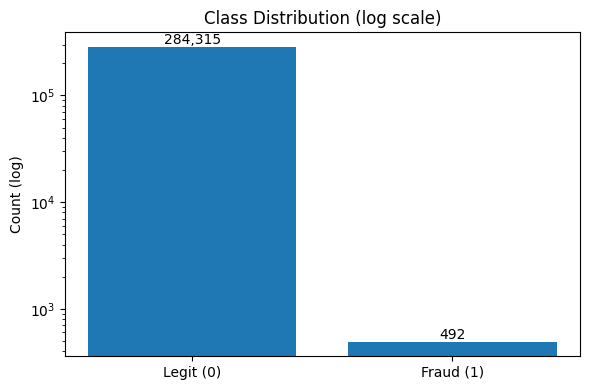

In [5]:
class_counts = df["Class"].value_counts().sort_index()
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Counts:\n", class_counts)
print("\nPercentages (%):\n", class_pct.round(4))

plt.figure(figsize=(6,4))
plt.bar(["Legit (0)", "Fraud (1)"], class_counts.values)
plt.yscale("log")
plt.title("Class Distribution (log scale)")
plt.ylabel("Count (log)")
for i, v in enumerate(class_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

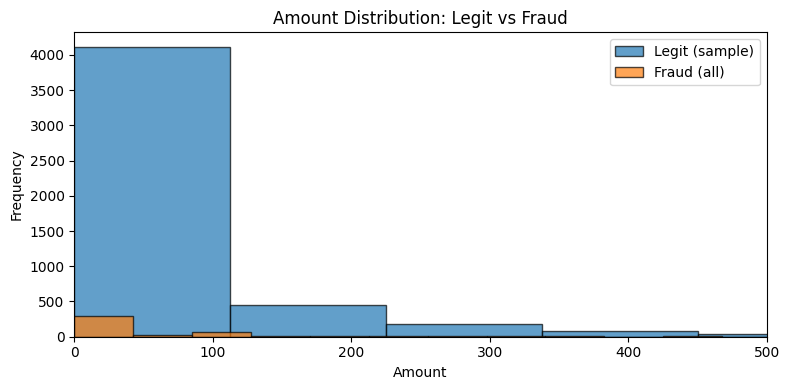

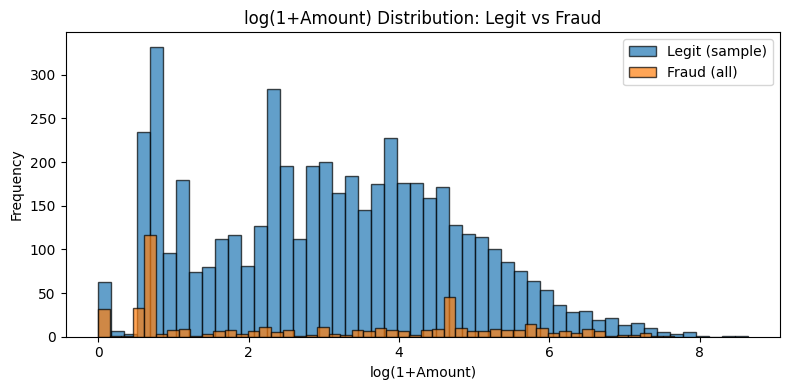

In [6]:
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

# sample legit for fair visualization (keep all fraud)
legit_sample = legit.sample(n=min(5000, len(legit)), random_state=42)

plt.figure(figsize=(8,4))
plt.hist(legit_sample["Amount"], bins=50, alpha=0.7, label="Legit (sample)", edgecolor="black")
plt.hist(fraud["Amount"], bins=50, alpha=0.7, label="Fraud (all)", edgecolor="black")
plt.title("Amount Distribution: Legit vs Fraud")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.xlim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()

# log transform to show tail better
plt.figure(figsize=(8,4))
plt.hist(np.log1p(legit_sample["Amount"]), bins=50, alpha=0.7, label="Legit (sample)", edgecolor="black")
plt.hist(np.log1p(fraud["Amount"]), bins=50, alpha=0.7, label="Fraud (all)", edgecolor="black")
plt.title("log(1+Amount) Distribution: Legit vs Fraud")
plt.xlabel("log(1+Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

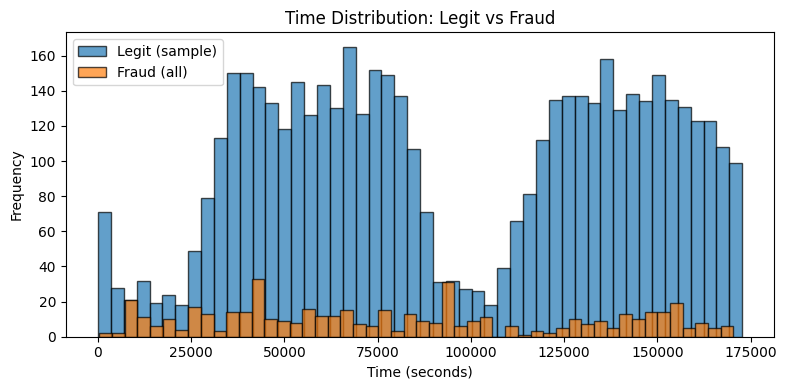

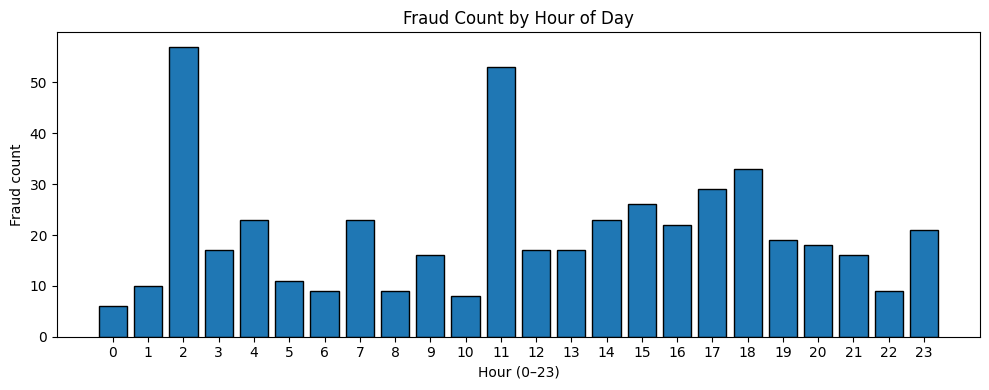

In [7]:
plt.figure(figsize=(8,4))
plt.hist(legit_sample["Time"], bins=50, alpha=0.7, label="Legit (sample)", edgecolor="black")
plt.hist(fraud["Time"], bins=50, alpha=0.7, label="Fraud (all)", edgecolor="black")
plt.title("Time Distribution: Legit vs Fraud")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Convert Time -> Hour of day
hour = (df["Time"] % 86400) / 3600
hour_int = hour.astype(int)

fraud_by_hour = df[df["Class"] == 1].groupby(hour_int).size()

plt.figure(figsize=(10,4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, edgecolor="black")
plt.title("Fraud Count by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Fraud count")
plt.xticks(range(0,24,1))
plt.tight_layout()
plt.show()

Top-10 features by |corr(Class)|:
       corr  abs_corr
V17 -0.3265    0.3265
V14 -0.3025    0.3025
V12 -0.2606    0.2606
V10 -0.2169    0.2169
V16 -0.1965    0.1965
V3  -0.1930    0.1930
V7  -0.1873    0.1873
V11  0.1549    0.1549
V4   0.1334    0.1334
V18 -0.1115    0.1115


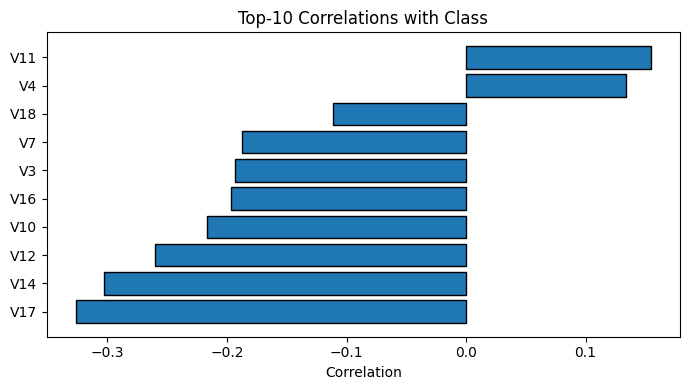

In [8]:
corr = df.corr(numeric_only=True)["Class"].drop("Class")
abs_corr = corr.abs().sort_values(ascending=False)

top10 = abs_corr.head(10)
print("Top-10 features by |corr(Class)|:")
print(pd.DataFrame({"corr": corr[top10.index], "abs_corr": top10}).round(4))

plt.figure(figsize=(7,4))
vals = corr[top10.index].sort_values()
plt.barh(vals.index, vals.values, edgecolor="black")
plt.title("Top-10 Correlations with Class")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## Висновки EDA

### Основні характеристики датасету

- Пропущені значення відсутні.
- Усі ознаки є числовими, що спрощує побудову моделей без додаткового кодування.
- Датасет критично незбалансований — частка шахрайських транзакцій становить менше 1%.

### Особливості задачі

З огляду на сильний дисбаланс класів:

- доцільно використовувати `class_weight="balanced"` у RandomForest;
- недоцільно орієнтуватися лише на accuracy;
- основними метриками оцінювання мають бути:
  - Precision
  - Recall
  - F1-score
  - PR-AUC 

### Обґрунтування вибору baseline-моделі

RandomForest обрано як базову модель, оскільки він:

- не потребує масштабування ознак;
- є стійким до нелінійних залежностей;
- менш чутливий до мультиколінеарності;
- дозволяє оцінити важливість ознак;
- ефективно працює з табличними даними.

### Подальші кроки

- виконати серію експериментів із різними значеннями гіперпараметра `max_depth`;
- порівняти результати за метриками на тренувальній і тестовій вибірках;
- дослідити вплив гіперпараметрів на перенавчання.
